# Modeling

In [1]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, cross_val_predict, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, make_scorer, roc_curve, ConfusionMatrixDisplay, fbeta_score)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from xgboost import XGBClassifier

In [2]:
DATA_DIR = r"D:\Ameng\Data Science Project\heart-failure-prediction\data"
df = pd.read_csv(os.path.join(DATA_DIR, "heart_failure_fe.csv"))

In [3]:
print(df.shape)
print(df.columns.tolist())

(299, 15)
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'egfr', 'ef_group']


In [4]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (299, 14)
y shape: (299,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (239, 14)
X_test: (60, 14)


In [6]:
print("Train target distribution:")
print(y_train.value_counts())

print("\nTrain target proportion:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts())

print("\nTest target proportion:")
print(y_test.value_counts(normalize=True))

Train target distribution:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64

Train target proportion:
DEATH_EVENT
0    0.677824
1    0.322176
Name: proportion, dtype: float64

Test target distribution:
DEATH_EVENT
0    41
1    19
Name: count, dtype: int64

Test target proportion:
DEATH_EVENT
0    0.683333
1    0.316667
Name: proportion, dtype: float64


In [7]:
def build_preprocessor():
    log_cols = ["creatinine_phosphokinase", "serum_creatinine", "platelets", "time", "egfr"]
    scale_cols = ["age", "ejection_fraction", "serum_sodium"]
    bin_cols = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking", "ef_group"]

    log_pipeline = Pipeline([
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler())
    ])
    
    scale_pipeline = Pipeline([
        ("scale", StandardScaler())
    ])

    return ColumnTransformer([
        ("log", log_pipeline, log_cols),
        ("scale", scale_pipeline, scale_cols),
        ("pass", "passthrough", bin_cols)
    ], verbose_feature_names_out=False)

## Cross Validation

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "AUC": make_scorer(roc_auc_score, response_method="predict_proba"),
    "F1": make_scorer(f1_score, zero_division=0),
    "PRE": make_scorer(precision_score, zero_division=0),
    "REC": make_scorer(recall_score, zero_division=0),
}

def cv_table(X, y, models):
    rows = []
    for name, model in models.items():
        r = {m: cross_val_score(model, X, y, cv=cv, scoring=s).mean().round(4)
             for m, s in scorers.items()}
        r |= {"model": name}; rows.append(r)
    return pd.DataFrame(rows).set_index("model")

In [9]:
preprocessor = build_preprocessor()

def make_model(est):
    return Pipeline([
        ("pre", preprocessor),
        ("model", est)
    ])

In [10]:
models = {
    "LogReg": make_model(LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")),
    "RandomForest": make_model(RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")),
    "SVM": make_model(CalibratedClassifierCV(SVC(kernel="rbf", class_weight="balanced"), ensemble=False)),
    "kNN": make_model(KNeighborsClassifier(n_neighbors=5)),
    "GradientBoosting": make_model(GradientBoostingClassifier(random_state=42)),
    "XGBoost": make_model(XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)),
}
result = cv_table(X_train, y_train, models)
print(result.round(4).sort_values("AUC", ascending=False))

                     AUC      F1     PRE     REC
model                                           
XGBoost           0.9146  0.7683  0.8113  0.7417
LogReg            0.9038  0.7803  0.7526  0.8167
RandomForest      0.9002  0.7586  0.7323  0.8067
SVM               0.8988  0.7477  0.7616  0.7400
GradientBoosting  0.8971  0.7108  0.7610  0.6908
kNN               0.8325  0.5954  0.8343  0.4808


In [11]:
top3_names = (result.sort_values("AUC", ascending=False).head(3).index.tolist())

print("Top 3 models:")
print(top3_names)

Top 3 models:
['XGBoost', 'LogReg', 'RandomForest']


Based on 5-fold cross-validation result, the top three models (XGBoost, Logistic Regression, and Random Forest) will be selected for hyperparameter tuning.

## Hyperparameter Tuning

In [12]:
param_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"]
}

param_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

param_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [13]:
grid_lr = GridSearchCV(
    make_model(LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")),
    param_grid=param_lr,
    cv=cv, scoring="roc_auc", n_jobs=-1)
grid_lr.fit(X_train, y_train)
print("Best param:", grid_lr.best_params_)
print("Best CV AUC:", grid_lr.best_score_.round(4))

Best param: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV AUC: 0.9103


d:\Ameng\Data Science Project\heart-failure-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [14]:
grid_rf = GridSearchCV(
    make_model(RandomForestClassifier(random_state=42, class_weight="balanced")),
    param_grid=param_rf,
    cv=cv, scoring="roc_auc", n_jobs=-1)

grid_rf.fit(X_train, y_train)

print("Best param:", grid_rf.best_params_)
print("Best CV AUC:", grid_rf.best_score_.round(4))

Best param: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV AUC: 0.9119


In [15]:
grid_xgb = GridSearchCV(
    make_model(XGBClassifier(random_state=42, eval_metric="logloss")),
    param_grid=param_xgb,
    cv=cv, scoring="roc_auc", n_jobs=1
)

grid_xgb.fit(X_train, y_train)

print("Best param:", grid_xgb.best_params_)
print("Best CV AUC:", grid_xgb.best_score_.round(4))

Best param: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV AUC: 0.9195


## Tuned Model Comparison

In [16]:
tuned_results = []

if "LogReg" in top3_names:
    tuned_results.append({
        "Model": "LogReg",
        "Best CV AUC": grid_lr.best_score_,
        "Best Parameters": grid_lr.best_params_
    })

if "RandomForest" in top3_names:
    tuned_results.append({
        "Model": "RandomForest",
        "Best CV AUC": grid_rf.best_score_,
        "Best Parameters": grid_rf.best_params_
    })

if "XGBoost" in top3_names:
    tuned_results.append({
        "Model": "XGBoost",
        "Best CV AUC": grid_xgb.best_score_,
        "Best Parameters": grid_xgb.best_params_
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df.sort_values("Best CV AUC", ascending=False).round(4)

,Model,Best CV AUC,Best Parameters
2,XGBoost,0.9195,"{'model__colsample_bytree': 0.8, 'model__learn..."
1,RandomForest,0.9119,"{'model__max_depth': 10, 'model__min_samples_l..."
0,LogReg,0.9103,"{'model__C': 0.1, 'model__penalty': 'l2'}"


In [17]:
final_models = {
    "LogReg": grid_lr.best_estimator_,
    "RandomForest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}
res_final = cv_table(X_train, y_train, final_models)
print(res_final.sort_values("AUC", ascending=False))

d:\Ameng\Data Science Project\heart-failure-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Ameng\Data Science Project\heart-failure-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  war

                 AUC      F1     PRE     REC
model                                       
XGBoost       0.9195  0.7408  0.7748  0.7150
RandomForest  0.9119  0.7582  0.7080  0.8317
LogReg        0.9103  0.7733  0.7498  0.8042


Based on hyperparameter tuning results using 5-fold cross-validation, XGBoost was selected as the best model candidate because it yielded the highest AUC (0.9195) and Precision (0.7748), with an F1-score (0.7408) close to that of Logistic Regression (0.7753). Although Random Forest achieved the highest Recall (0.8317), XGBoost delivered superior overall performance based on the combination of evaluation metrics.

In [18]:
def select_recall_threshold(y_true, y_proba, target_recall=0.80):
    thresholds = np.arange(0.05, 0.96, 0.01)
    threshold_results = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        threshold_results.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        })

    threshold_df = pd.DataFrame(threshold_results)
    eligible = threshold_df[threshold_df["recall"] >= target_recall]

    if not eligible.empty:
        best_t = eligible.sort_values(["precision", "f2"], ascending=False).iloc[0]["threshold"]
    else:
        best_t = threshold_df.sort_values(["recall", "f2"], ascending=False).iloc[0]["threshold"]

    selected = threshold_df.iloc[(threshold_df["threshold"] - best_t).abs().argmin()].copy()

    return float(best_t), threshold_df, selected

In [19]:
target_recall = 0.80
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_ratio = neg_count / pos_count
scale_pos_weight_values = sorted(set([1.0, 1.5, 2.0, round(float(class_ratio), 2), 2.5, 3.0]))

print("Negative samples:", neg_count)
print("Positive samples:", pos_count)
print("Class ratio:", round(class_ratio, 4))
print("Scale_pos_weight candidates:", scale_pos_weight_values)

Negative samples: 162
Positive samples: 77
Class ratio: 2.1039
Scale_pos_weight candidates: [1.0, 1.5, 2.0, 2.1, 2.5, 3.0]


In [20]:
candidate_results = []

for weight in scale_pos_weight_values:
    candidate_model = clone(grid_xgb.best_estimator_)
    candidate_model.set_params(model__scale_pos_weight=weight)
    candidate_oof = cross_val_predict(candidate_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1)[:, 1]

    candidate_best_t, candidate_threshold_df, candidate_selected = (
        select_recall_threshold(y_train, candidate_oof, target_recall=target_recall)
    )

    candidate_results.append({
        "scale_pos_weight": weight,
        "oof_auc": roc_auc_score(y_train, candidate_oof),
        "best_threshold": candidate_best_t,
        "oof_precision": candidate_selected["precision"],
        "oof_recall": candidate_selected["recall"],
        "oof_f1": candidate_selected["f1"],
        "oof_f2": candidate_selected["f2"]
    })

candidate_results_df = pd.DataFrame(candidate_results)
display(candidate_results_df.sort_values(
    ["oof_recall", "oof_precision", "oof_f2"],
    ascending=False
).round(4))

,scale_pos_weight,oof_auc,best_threshold,oof_precision,oof_recall,oof_f1,oof_f2
0,1.0,0.9165,0.34,0.7683,0.8182,0.7925,0.8077
1,1.5,0.9166,0.39,0.7412,0.8182,0.7778,0.8015
5,3.0,0.9130,0.51,0.7326,0.8182,0.7730,0.7995
4,2.5,0.9131,0.50,0.7654,0.8052,0.7848,0.7969
2,2.0,0.9161,0.47,0.7561,0.8052,0.7799,0.7949
3,2.1,0.9141,0.48,0.7561,0.8052,0.7799,0.7949


In [21]:
eligible_candidates = candidate_results_df[candidate_results_df["oof_recall"] >= target_recall]

if not eligible_candidates.empty:
    winner = eligible_candidates.sort_values(
        ["oof_precision", "oof_f2", "oof_auc"],
        ascending=False
    ).iloc[0]
else:
    winner = candidate_results_df.sort_values(
        ["oof_recall", "oof_f2", "oof_auc"],
        ascending=False
    ).iloc[0]

best_scale_pos_weight = float(winner["scale_pos_weight"])

print("Selected scale_pos_weight:", best_scale_pos_weight)
display(winner.to_frame().T.round(4))

Selected scale_pos_weight: 1.0


,scale_pos_weight,oof_auc,best_threshold,oof_precision,oof_recall,oof_f1,oof_f2
0,1.0,0.9165,0.34,0.7683,0.8182,0.7925,0.8077


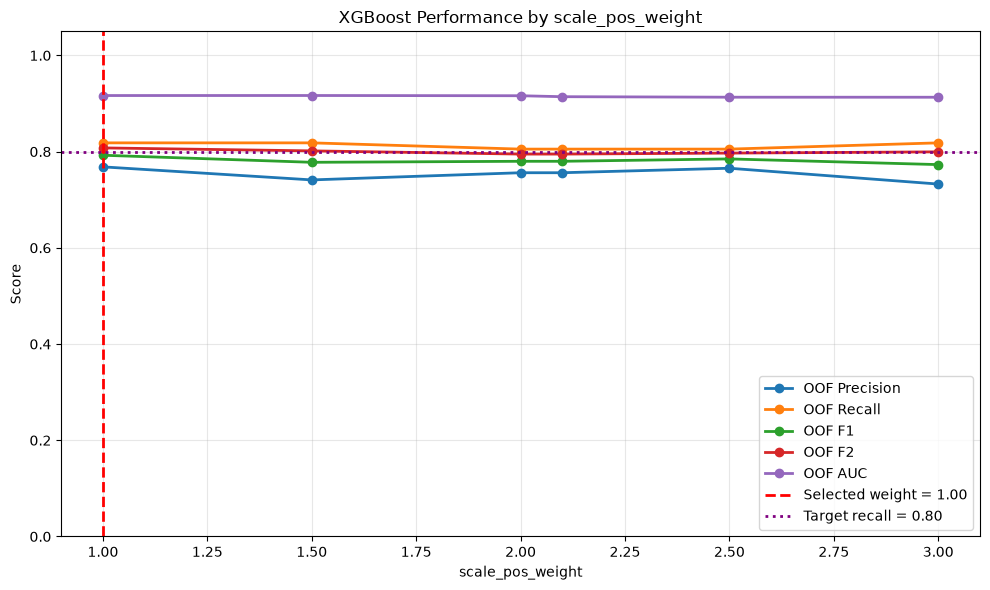

In [22]:
plot_df = candidate_results_df.sort_values("scale_pos_weight")
fig, ax = plt.subplots(figsize=(10, 6))
metrics_to_plot = {
    "oof_precision": "OOF Precision",
    "oof_recall": "OOF Recall",
    "oof_f1": "OOF F1",
    "oof_f2": "OOF F2",
    "oof_auc": "OOF AUC"
}

for column, label in metrics_to_plot.items():
    ax.plot(plot_df["scale_pos_weight"], plot_df[column], marker="o", linewidth=2, label=label)

ax.axvline(best_scale_pos_weight,color="red",linestyle="--",linewidth=2,label=(
        f"Selected weight = "
        f"{best_scale_pos_weight:.2f}"
        ))
ax.axhline(target_recall, color="purple", linestyle=":", linewidth=2, label=f"Target recall = {target_recall:.2f}")
ax.set_title("XGBoost Performance by scale_pos_weight")
ax.set_xlabel("scale_pos_weight")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [23]:
best_model = clone(grid_xgb.best_estimator_)
best_model.set_params(model__scale_pos_weight=best_scale_pos_weight)
best_model.fit(X_train, y_train)

print("Best model: XGBoost")
print("Selected scale_pos_weight:", best_scale_pos_weight)
print("Original best CV AUC:", round(grid_xgb.best_score_, 4))

Best model: XGBoost
Selected scale_pos_weight: 1.0
Original best CV AUC: 0.9195


In [24]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_proba)
test_f1 = f1_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

print(f"Test AUC: {test_auc:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

Test AUC: 0.8665
Test F1: 0.6875
Test Precision: 0.8462
Test Recall: 0.5789


## Threshold Optimization
F1, Precision, and Recall depend on the decision cut-off. With imbalanced data (68:32), the default threshold of 0.5 is rarely optimal. <br>
The threshold is selected based on out-of-fold (OOF) CV, not the test set, to ensure the cut-off selection is unbiased. AUC is unaffected by the threshold.

In [25]:
oof = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1)[:, 1]
best_t, threshold_df, selected = (select_recall_threshold(y_train, oof, target_recall=target_recall))

In [26]:
print(f"Target recall: {target_recall:.2f}")
print(f"Selected threshold: {best_t:.2f}")

display(selected.to_frame().T.round(4))

Target recall: 0.80
Selected threshold: 0.34


,threshold,precision,recall,f1,f2
29,0.34,0.7683,0.8182,0.7925,0.8077


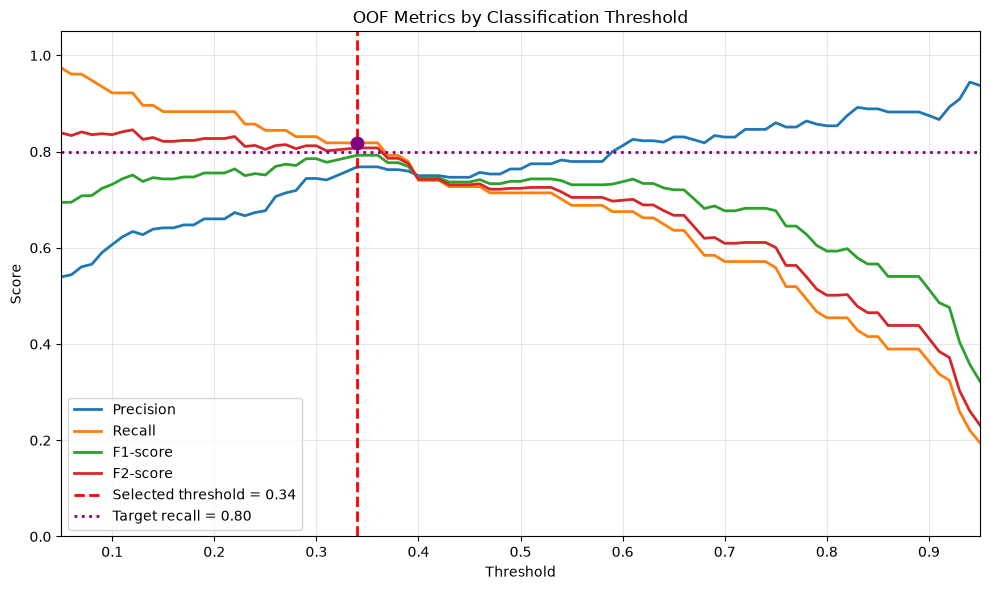

In [27]:
plot_df = threshold_df.sort_values("threshold")

fig, ax = plt.subplots(figsize=(10, 6))

metrics_to_plot = {
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-score",
    "f2": "F2-score"
}

for column, label in metrics_to_plot.items():
    ax.plot(plot_df["threshold"], plot_df[column], linewidth=2, label=label)

ax.axvline(best_t, color="red", linestyle="--", linewidth=2, label=f"Selected threshold = {best_t:.2f}")
ax.axhline(target_recall, color="purple", linestyle=":", linewidth=2, label=f"Target recall = {target_recall:.2f}")
ax.scatter(best_t, selected["recall"], color="purple", s=80, zorder=5)
ax.set_title("OOF Metrics by Classification Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [28]:
y_pred_default = (y_proba >= 0.50).astype(int)
y_pred_opt = (y_proba >= best_t).astype(int)

rows = []
for name, yp in [("default (0.5)", y_pred_default),
                 (f"recall-optimized ({best_t:.2f})", y_pred_opt)]:
    rows.append({"threshold": name,
                 "F1": f1_score(y_test, yp, zero_division=0),
                 "Precision": precision_score(y_test, yp, zero_division=0),
                 "Recall": recall_score(y_test, yp, zero_division=0)})

test_threshold_results = pd.DataFrame(rows)
display(test_threshold_results.round(4))
print("Test AUC:", round(test_auc, 4))

,threshold,F1,Precision,Recall
0,default (0.5),0.6875,0.8462,0.5789
1,recall-optimized (0.34),0.7027,0.7222,0.6842


Test AUC: 0.8665


## Results Visualization

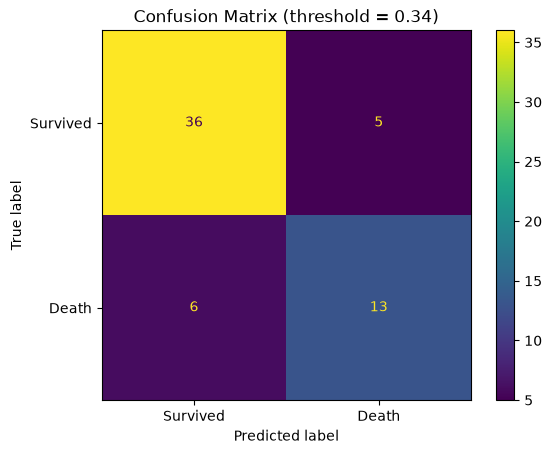

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt,
    display_labels=["Survived", "Death"])
plt.title(f"Confusion Matrix (threshold = {best_t:.2f})")
plt.show()

The confusion matrix employs a threshold selected based on the target recall derived from OOF probabilities. Evaluation on the test set is used to measure the model's final performance.

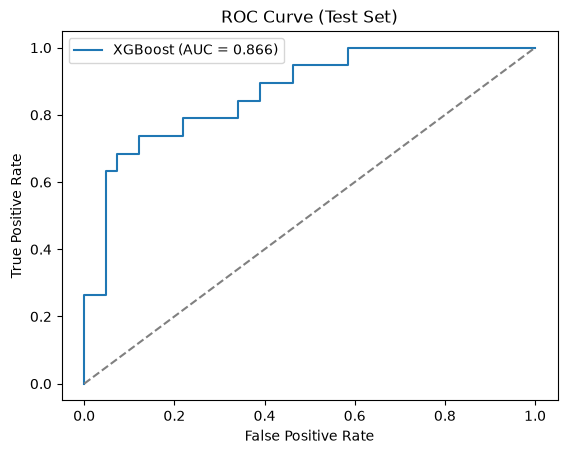

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve (Test Set)")
plt.show()

The XGBoost ROC curve on the test set yielded an AUC of 0.866. This result is based on the XGBoost model using the selected `scale_pos_weight`.

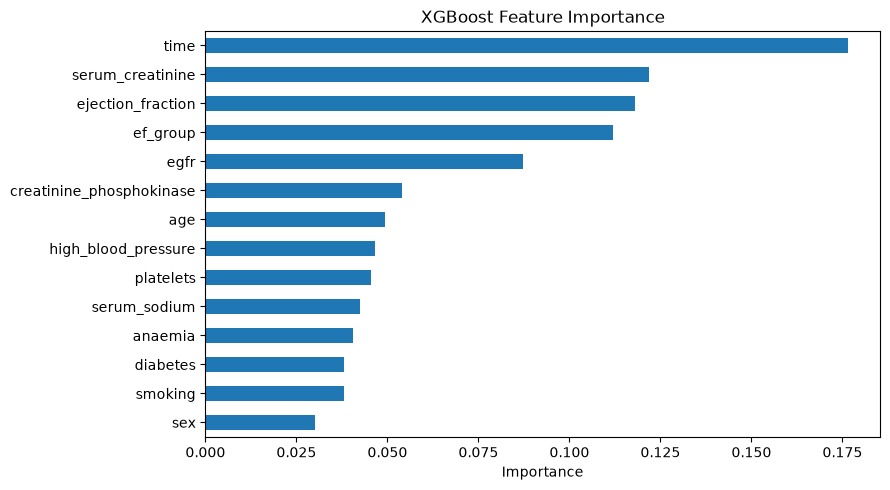

In [31]:
steps = list(best_model.named_steps)
model_step = best_model.named_steps[steps[-1]]
pre_step = best_model.named_steps[steps[0]] 

if hasattr(model_step, "feature_importances_"):
    feature_names = pre_step.get_feature_names_out()
    imp = pd.Series(model_step.feature_importances_, index=feature_names).sort_values()
    imp.plot(kind="barh", figsize=(9, 5))
    plt.title("XGBoost Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

XGBoost feature importance indicates that `time` is the most dominant feature in the prediction, followed by `serum_creatinine` and `ejection_fraction`. `Age` also makes a significant contribution, whereas `diabetes` and `high_blood_pressure` have relatively low importance. Feature importance reflects the extent of a feature's contribution to the model but does not indicate the direction of its influence on the prediction.

## Export Model Result

In [32]:
MODELS_DIR = r"D:\Ameng\Data Science Project\heart-failure-prediction\models"
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(best_model, os.path.join(MODELS_DIR, "model.joblib"))

metrics = pd.DataFrame([
    {"metric": "AUC", "value": test_auc},
    {"metric": "F1 (recall optimized)", "value": f1_score(y_test, y_pred_opt, zero_division=0)},
    {"metric": "Precision (recall optimized)", "value": precision_score(y_test, y_pred_opt, zero_division=0)},
    {"metric": "Recall (recall optimized)", "value": recall_score(y_test, y_pred_opt, zero_division=0)},
    {"metric": "scale_pos_weight", "value": float(best_scale_pos_weight)},
    {"metric": "best_threshold", "value": best_t},
    {"metric": "target_recall", "value": float(target_recall)},
    {"metric": "OOF precision at threshold", "value": float(selected["precision"])},
    {"metric": "OOF recall at threshold", "value": float(selected["recall"])},
    {"metric": "OOF F1 at threshold", "value": float(selected["f1"])},
    {"metric": "OOF F2 at threshold", "value": float(selected["f2"])}
])
metrics.to_csv(os.path.join(MODELS_DIR, "metrics_test.csv"), index=False)
candidate_results_df.to_csv(os.path.join(MODELS_DIR, "scale_pos_weight_results.csv"), index=False)
print("Model, metrics & candidates saved to:", MODELS_DIR)

Model, metrics & candidates saved to: D:\Ameng\Data Science Project\heart-failure-prediction\models


In [33]:
preprocessor = best_model.named_steps["pre"]
joblib.dump(preprocessor, os.path.join(MODELS_DIR, "preprocessor.joblib"))
print("Preprocessor saved to:", MODELS_DIR)

Preprocessor saved to: D:\Ameng\Data Science Project\heart-failure-prediction\models
